In [3]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist, cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten, Input, BatchNormalization
from keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
import time
from sklearn.metrics import accuracy_score
import psutil
from keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img, ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam, SGD
import pandas as pd

In [3]:
# Loading and preprocessing the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data() 

In [5]:
# Reshaping the data to suit greyscale images
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32')

In [7]:
#Normalising data to help with training
x_train /= 255
x_test /= 255

In [9]:
# Using one-hot encoding on labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [11]:
#checking shape
n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

Shape before one-hot encoding:  (60000, 10)
Shape after one-hot encoding:  (60000, 10, 10)


## Basic CNN without distributed training

In [14]:
# Track CPU and memory usage before training
cpu_usage_before = psutil.cpu_percent(interval=1)
memory_before = psutil.virtual_memory().percent
print(f"CPU usage before training: {cpu_usage_before}%")
print(f"Memory usage before training: {memory_before}%")

# Check GPU usage (if available)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        memory_info = tf.config.experimental.get_memory_info(gpu)
        print(f"GPU Memory info before training: {memory_info}")
else:
    print("No GPU found.")

# Track the time before training
start_time = time.time()

CPU usage before training: 1.0%
Memory usage before training: 51.5%
No GPU found.


In [23]:
# Building the CNN model
model = Sequential()
#Input layer (to avoid warning)
model.add(Input(shape=(28, 28, 1)))

# First Convolutional Layer
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Second convonutional layer
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Third Convolutional Layer (256 filters)
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))

# flattening convolutional layer's outputs
model.add(Flatten())

# first dense layer, fully connected
model.add(Dense(512, activation='relu'))

# Dropout Layer to help reduce overfitting
model.add(Dropout(0.2))

# Output layer- another fully connected dense layer- softmax for probability
model.add(Dense(10, activation='softmax'))

In [25]:
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [27]:
# TensorBoard setup to track the experiment (useful for comparisons later)
log_dir = "logs/no_distributed"
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [29]:
# Train model
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test), callbacks=[tensorboard_callback])

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 113s 115ms/step - accuracy: 0.7760 - loss: 0.6094 - val_accuracy: 0.8900 - val_loss: 0.2929
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 110s 117ms/step - accuracy: 0.8980 - loss: 0.2732 - val_accuracy: 0.9051 - val_loss: 0.2515
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 106s 113ms/step - accuracy: 0.9214 - loss: 0.2178 - val_accuracy: 0.9135 - val_loss: 0.2328
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 108s 115ms/step - accuracy: 0.9310 - loss: 0.1826 - val_accuracy: 0.9178 - val_loss: 0.2312
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 108s 115ms/step - accuracy: 0.9429 - loss: 0.1554 - val_accuracy: 0.9182 - val_loss: 0.2450
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 106s 113ms/step - accuracy: 0.9513 - loss: 0.1310 - val_accuracy: 0.9162 - val_loss: 0.2378
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 108s 115ms/step - accuracy: 0.9580 - loss: 0.1111 - val_accuracy: 0.9166 - val_loss: 0.2500
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 131s 140ms/step - accuracy: 0.9631 -

In [30]:
# Track time after training
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

# Track CPU and memory usage after training
cpu_usage_after = psutil.cpu_percent(interval=1)
memory_after = psutil.virtual_memory().percent
print(f"CPU usage after training: {cpu_usage_after}%")
print(f"Memory usage after training: {memory_after}%")

Training time: 1104.65 seconds
CPU usage after training: 18.8%
Memory usage after training: 50.5%


In [31]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"[No Distributed] Test loss: {test_loss:.4f}, Test accuracy: {test_accuracy:.4f}")

[No Distributed] Test loss: 0.2812, Test accuracy: 0.9217


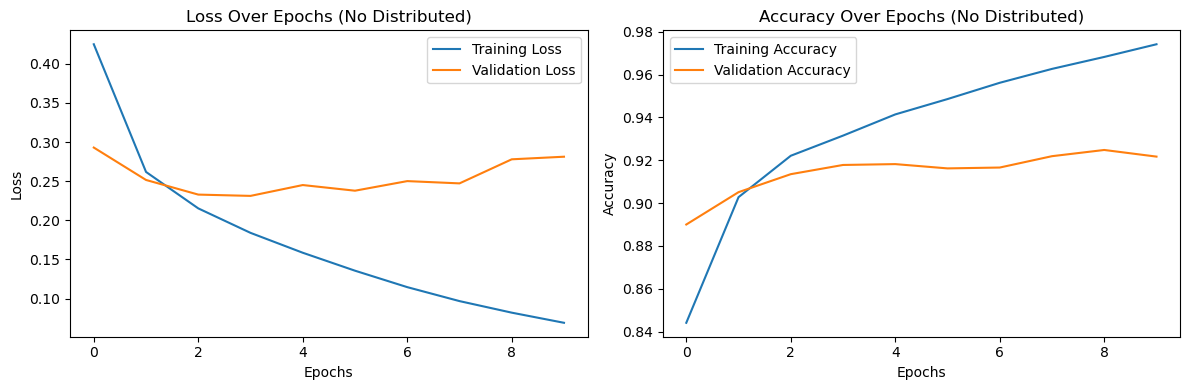

In [32]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs (No Distributed)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs (No Distributed)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Making predictions
y_pred = model.predict(x_test)

# Converting predictions from one-hot encoding to integer labels
y_pred_labels = np.argmax(y_pred, axis=1)  # Predicted labels

# Converting y_test from one-hot encoding to integer labels (true labels)
y_true_labels = np.argmax(y_test, axis=1)  # True labels

# Calculate accuracy using sklearn's accuracy_score
acc = accuracy_score(y_true_labels, y_pred_labels)
print(f"Accuracy using sklearn's accuracy_score: {acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Accuracy using sklearn's accuracy_score: 0.9217


In [34]:
# List of clothing names corresponding to each class index
clothing_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", 
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Map the integer labels to clothing names for both true and predicted labels
y_pred_clothing = [clothing_names[label] for label in y_pred_labels]
y_true_clothing = [clothing_names[label] for label in y_true_labels]

# example predictions:
print(f"True labels: {y_true_clothing[:5]}")  # Showing the first 5 true clothing names
print(f"Predicted labels: {y_pred_clothing[:5]}")  # Showing the first 5 predicted clothing names

True labels: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt']
Predicted labels: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt']


In [35]:
#saving the model
model.save('fashion_mnist_cnn_model.keras')

print("Model saved successfully.")

Model saved successfully.


## Model with Distributed training

In [47]:
# Set up distributed strategy
strategy = tf.distribute.MirroredStrategy()
print(f"Using {strategy.num_replicas_in_sync} replicas for distributed training.")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
Using 1 replicas for distributed training.


In [48]:
# Track CPU and memory usage before training
cpu_usage_before = psutil.cpu_percent(interval=1)
memory_before = psutil.virtual_memory().percent
print(f"CPU usage before training: {cpu_usage_before}%")
print(f"Memory usage before training: {memory_before}%")

# Track the time before training
start_time = time.time()

CPU usage before training: 2.0%
Memory usage before training: 51.4%


In [49]:
# Model building within strategy scope
with strategy.scope():
    dist_model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPool2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPool2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPool2D((2, 2)),
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.2),
        Dense(10, activation='softmax')
    ])

    # Compile model
    dist_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [50]:
# TensorBoard setup - to track experiment for comparison with the last model
log_dir = "logs/distributed"
dist_tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [51]:
# Train model
dist_history = dist_model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test), callbacks=[dist_tensorboard_callback])

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 93s 98ms/step - accuracy: 0.7670 - loss: 0.6309 - val_accuracy: 0.8796 - val_loss: 0.3329
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 90s 95ms/step - accuracy: 0.9013 - loss: 0.2691 - val_accuracy: 0.9010 - val_loss: 0.2700
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 86s 92ms/step - accuracy: 0.9210 - loss: 0.2126 - val_accuracy: 0.9113 - val_loss: 0.2443
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.9330 - loss: 0.1838 - val_accuracy: 0.9183 - val_loss: 0.2254
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 89s 95ms/step - accuracy: 0.9411 - loss: 0.1554 - val_accuracy: 0.9208 - val_loss: 0.2183
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 91ms/step - accuracy: 0.9509 - loss: 0.1300 - val_accuracy: 0.9162 - val_loss: 0.2319
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 86s 91ms/step - accuracy: 0.9589 - loss: 0.1098 - val_accuracy: 0.9219 - val_loss: 0.2425
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 92s 98ms/step - accuracy: 0.9651 - loss: 0.0920 - 

In [52]:
# Track time after training
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

# Track CPU and memory usage after training
cpu_usage_after = psutil.cpu_percent(interval=1)
memory_after = psutil.virtual_memory().percent
print(f"CPU usage after training: {cpu_usage_after}%")
print(f"Memory usage after training: {memory_after}%")

Training time: 878.61 seconds
CPU usage after training: 2.9%
Memory usage after training: 52.8%


In [53]:
# Evaluate model
dist_test_loss, dist_test_accuracy = dist_model.evaluate(x_test, y_test, verbose=0)
print(f"[Distributed] Test loss: {dist_test_loss:.4f}, Test accuracy: {dist_test_accuracy:.4f}")

[Distributed] Test loss: 0.2864, Test accuracy: 0.9215


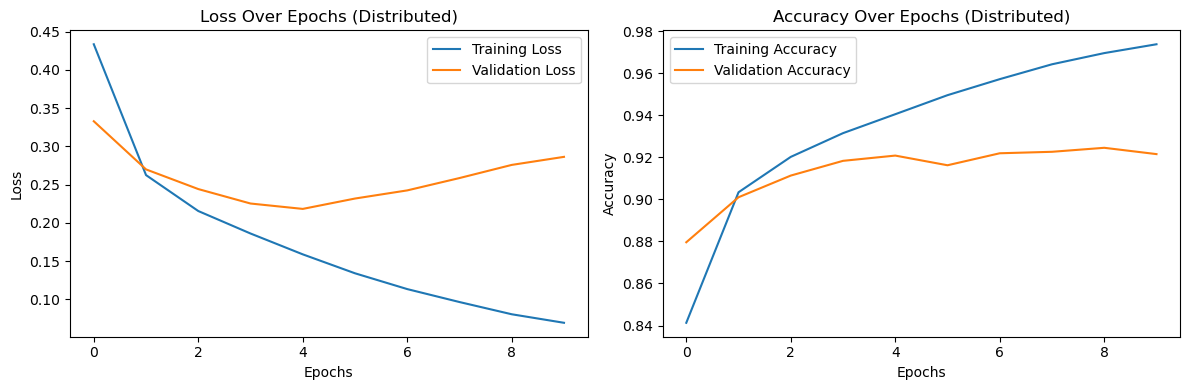

To view TensorBoard, use: tensorboard --logdir=logs/


In [54]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(dist_history.history['loss'], label='Training Loss')
plt.plot(dist_history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs (Distributed)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(dist_history.history['accuracy'], label='Training Accuracy')
plt.plot(dist_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs (Distributed)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print("To view TensorBoard, use: tensorboard --logdir=logs/")

In [55]:
# Making predictions
dist_y_pred = dist_model.predict(x_test)

# Converting predictions from one-hot encoding to integer labels
dist_y_pred_labels = np.argmax(dist_y_pred, axis=1)  # Predicted labels

# Converting y_test from one-hot encoding to integer labels (true labels)
dist_y_true_labels = np.argmax(y_test, axis=1)  # True labels

# Calculating accuracy 
dist_acc = accuracy_score(dist_y_true_labels, dist_y_pred_labels)
print(f"[Distributed] Accuracy using sklearn's accuracy_score: {dist_acc}")

# Mapping the integer labels to clothing names for both true and predicted labels
dist_y_pred_clothing = [clothing_names[label] for label in dist_y_pred_labels]
dist_y_true_clothing = [clothing_names[label] for label in dist_y_true_labels]


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step
[Distributed] Accuracy using sklearn's accuracy_score: 0.9215


In [56]:
# Example predictions
print(f"[Distributed] True labels: {dist_y_true_clothing[:5]}")
print(f"[Distributed] Predicted labels: {dist_y_pred_clothing[:5]}")

[Distributed] True labels: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt']
[Distributed] Predicted labels: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt']


In [57]:
# Saving the distributed model
dist_model.save('fashion_mnist_dist_model.keras')
print("Distributed model saved successfully.")

Distributed model saved successfully.


## CIFAR10 dataset 
Will now look at how this model performs with CIFAR10, I will then test distributed training on this model. Once I have a baseline for these models on this dataset I will then run experiments with different optimization tools to see how this impacts the model.

In [13]:
# Load and preprocess CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

#astype 32...Reshaping to suit RGB images (CIFAR 10 is 32x32x3)
#/255 to normalise
x_train, x_val, y_train, y_val = train_test_split(x_train.astype('float32') / 255, to_categorical(y_train, 10),
                                                  test_size=0.2, random_state=42)
x_test = x_test.astype('float32') / 255
y_test = to_categorical(y_test, 10) #using one-hot encoding
cifar10_classes = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

In [60]:
# Checking shape of labels
n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
print("Shape after one-hot encoding: ", y_train.shape)

Shape before one-hot encoding:  (40000, 10)
Shape after one-hot encoding:  (40000, 10)


In [61]:
# Track CPU and memory usage before training
cpu_usage_before = psutil.cpu_percent(interval=1)
memory_before = psutil.virtual_memory().percent
print(f"CPU usage before training: {cpu_usage_before}%")
print(f"Memory usage before training: {memory_before}%")

CPU usage before training: 23.3%
Memory usage before training: 58.3%


In [62]:
# Non-distributed CNN
def build_basic_cnn():
    model = Sequential([
        Input(shape=(32, 32, 3)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPool2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPool2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPool2D((2, 2)),
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.2),
        Dense(10, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [63]:
# Build and train basic CNN models
basic_cnn = build_basic_cnn()

In [64]:
# Train Non-distributed CNN... increasing batch size due to more complex dataset
start_time = time.time()
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
basic_cnn_history = basic_cnn.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val),
                                  verbose=1, callbacks=[early_stopping])

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 225ms/step - accuracy: 0.3480 - loss: 1.7752 - val_accuracy: 0.5731 - val_loss: 1.1920
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 208ms/step - accuracy: 0.6002 - loss: 1.1233 - val_accuracy: 0.6691 - val_loss: 0.9466
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.6826 - loss: 0.9032 - val_accuracy: 0.7071 - val_loss: 0.8377
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 205ms/step - accuracy: 0.7385 - loss: 0.7455 - val_accuracy: 0.7242 - val_loss: 0.7996
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.7832 - loss: 0.6223 - val_accuracy: 0.7281 - val_loss: 0.7865
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 205ms/step - accuracy: 0.8137 - loss: 0.5277 - val_accuracy: 0.7591 - val_loss: 0.7094
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 256ms/step - accuracy: 0.8516 - loss: 0.4271 - val_accuracy: 0.7634 - val_loss: 0.7127
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 251ms/step - accuracy: 0.8800 - loss: 0

In [65]:
# Track CPU and memory usage after training
cpu_after, memory_after = psutil.cpu_percent(interval=1), psutil.virtual_memory().percent
print(f'CPU after training (basic CNN): {cpu_after}%')
print(f'Memory after training (basic CNN): {memory_after}%')

CPU after training (basic CNN): 2.2%
Memory after training (basic CNN): 54.7%


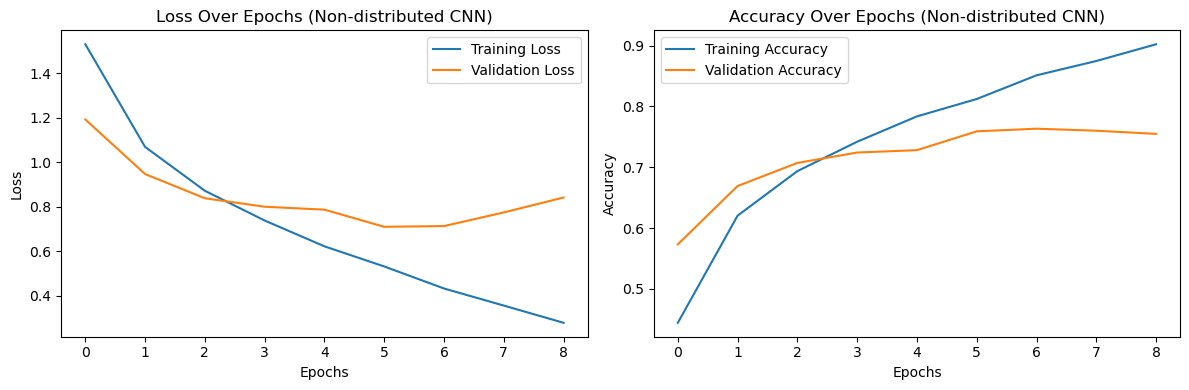

In [66]:
# Plot training history for non-distributed CNN
plt.figure(figsize=(12, 4))
# Loss
plt.subplot(1, 2, 1)
plt.plot(basic_cnn_history.history['loss'], label='Training Loss')
plt.plot(basic_cnn_history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs (Non-distributed CNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(basic_cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(basic_cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs (Non-distributed CNN)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Distributed CNN training using MirroredStrategy

In [68]:
# Distributed CNN with MirroredStrategy
strategy = tf.distribute.MirroredStrategy()
print(f"Using {strategy.num_replicas_in_sync} replicas for distributed training.")

# Building the model inside strategy scope
with strategy.scope():
    distributed_cnn = build_basic_cnn()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
Using 1 replicas for distributed training.


In [69]:
# Train Distributed CNN
start_time = time.time()
distributed_cnn_history = distributed_cnn.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val),
                                              verbose=1, callbacks=[early_stopping])

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 200ms/step - accuracy: 0.3144 - loss: 1.8685 - val_accuracy: 0.5176 - val_loss: 1.3182
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.5743 - loss: 1.2024 - val_accuracy: 0.6492 - val_loss: 1.0050
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 197ms/step - accuracy: 0.6725 - loss: 0.9309 - val_accuracy: 0.6910 - val_loss: 0.8758
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 201ms/step - accuracy: 0.7284 - loss: 0.7800 - val_accuracy: 0.6935 - val_loss: 0.8947
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 199ms/step - accuracy: 0.7739 - loss: 0.6577 - val_accuracy: 0.7336 - val_loss: 0.7744
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.8075 - loss: 0.5513 - val_accuracy: 0.7284 - val_loss: 0.8016
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 198ms/step - accuracy: 0.8354 - loss: 0.4723 - val_accuracy: 0.7615 - val_loss: 0.7113
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.8695 - loss: 0

In [70]:
# Track CPU and memory usage after distributed training
cpu_after_dist, memory_after_dist = psutil.cpu_percent(interval=1), psutil.virtual_memory().percent
print(f'CPU after training (distributed CNN): {cpu_after_dist}%')
print(f'Memory after training (distributed CNN): {memory_after_dist}%')

CPU after training (distributed CNN): 1.8%
Memory after training (distributed CNN): 56.2%


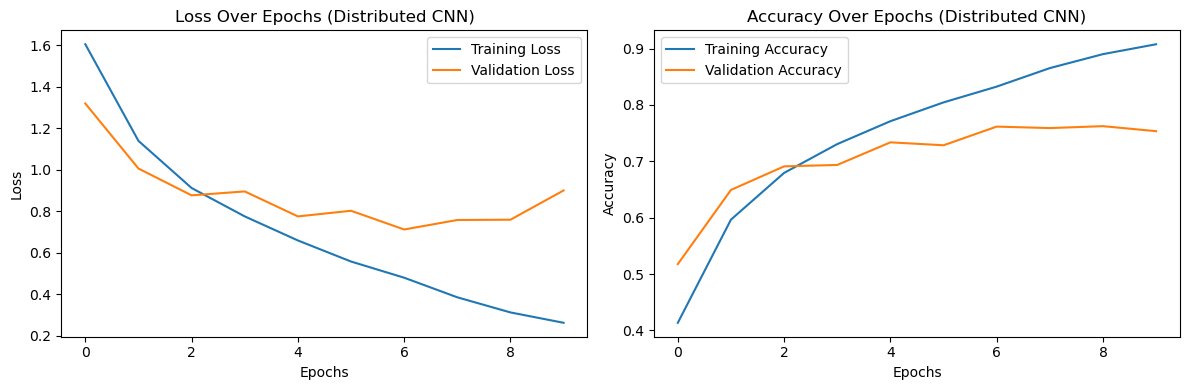

In [71]:
# Plot training history for distributed CNN
plt.figure(figsize=(12, 4))
# Loss
plt.subplot(1, 2, 1)
plt.plot(distributed_cnn_history.history['loss'], label='Training Loss')
plt.plot(distributed_cnn_history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs (Distributed CNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(distributed_cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(distributed_cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs (Distributed CNN)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [72]:
# Making predictions for Non-distributed CNN
y_pred_basic = basic_cnn.predict(x_test)

# Converting predictions from one-hot encoding to integer labels
y_pred_basic_labels = np.argmax(y_pred_basic, axis=1)  # Predicted labels

# Converting y_test from one-hot encoding to integer labels (true labels)
y_true_labels = np.argmax(y_test, axis=1)  # True labels

# Calculate accuracy using sklearn's accuracy_score
acc_basic = accuracy_score(y_true_labels, y_pred_basic_labels)
print(f"Accuracy using sklearn's accuracy_score for Non-distributed CNN: {acc_basic}")

# Making predictions for Distributed CNN
y_pred_dist = distributed_cnn.predict(x_test)

# Converting predictions from one-hot encoding to integer labels
y_pred_dist_labels = np.argmax(y_pred_dist, axis=1)  # Predicted labels

# Calculate accuracy using sklearn's accuracy_score
acc_dist = accuracy_score(y_true_labels, y_pred_dist_labels)
print(f"Accuracy using sklearn's accuracy_score for Distributed CNN: {acc_dist}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Accuracy using sklearn's accuracy_score for Non-distributed CNN: 0.7576
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
Accuracy using sklearn's accuracy_score for Distributed CNN: 0.7535


In [73]:
# List of CIFAR-10 class names corresponding to each class index
cifar10_classes = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer", 
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

In [74]:
# 1. Making predictions on non-distributed CNN
y_pred_basic = basic_cnn.predict(x_test)

# Converting predictions from one-hot encoding to integer labels
y_pred_basic_labels = np.argmax(y_pred_basic, axis=1)  # Predicted labels

# Converting y_test from one-hot encoding to integer labels (true labels)
y_true_labels = np.argmax(y_test, axis=1)  # True labels

# Mapping the integer labels to class names for both true and predicted labels
y_pred_basic_classes = [cifar10_classes[label] for label in y_pred_basic_labels]
y_true_classes = [cifar10_classes[label] for label in y_true_labels]

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


In [75]:
# Example predictions:
print(f"True labels (Non-distributed CNN): {y_true_classes[:5]}")  # Showing the first 5 true class names
print(f"Predicted labels (Non-distributed CNN): {y_pred_basic_classes[:5]}")  # Showing the first 5 predicted class names

# Calculate accuracy using sklearn's accuracy_score
acc_basic = accuracy_score(y_true_labels, y_pred_basic_labels)
print(f"Accuracy using sklearn's accuracy_score for Non-distributed CNN: {acc_basic}")

True labels (Non-distributed CNN): ['Cat', 'Ship', 'Ship', 'Airplane', 'Frog']
Predicted labels (Non-distributed CNN): ['Cat', 'Ship', 'Ship', 'Airplane', 'Frog']
Accuracy using sklearn's accuracy_score for Non-distributed CNN: 0.7576


In [76]:
# Save the non-distributed CNN model
basic_cnn.save('cifar10_basic_cnn_model.keras')
print("Non-distributed CNN model saved successfully.")

Non-distributed CNN model saved successfully.


In [77]:
# Making predictions on distributed CNN 
y_pred_dist = distributed_cnn.predict(x_test)

# Converting predictions from one-hot encoding to integer labels
y_pred_dist_labels = np.argmax(y_pred_dist, axis=1)  # Predicted labels

# Map the integer labels to class names for both true and predicted labels
y_pred_dist_classes = [cifar10_classes[label] for label in y_pred_dist_labels]

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


In [78]:
# Example predictions:
print(f"True labels (Distributed CNN): {y_true_classes[:5]}")  # Showing the first 5 true class names
print(f"Predicted labels (Distributed CNN): {y_pred_dist_classes[:5]}")  # Showing the first 5 predicted class names

# Calculate accuracy using sklearn's accuracy_score
acc_dist = accuracy_score(y_true_labels, y_pred_dist_labels)
print(f"Accuracy using sklearn's accuracy_score for Distributed CNN: {acc_dist}")

True labels (Distributed CNN): ['Cat', 'Ship', 'Ship', 'Airplane', 'Frog']
Predicted labels (Distributed CNN): ['Cat', 'Ship', 'Ship', 'Airplane', 'Frog']
Accuracy using sklearn's accuracy_score for Distributed CNN: 0.7535


In [79]:
# Save the distributed CNN model
distributed_cnn.save('cifar10_distributed_cnn_model.keras')
print("Distributed CNN model saved successfully.")

Distributed CNN model saved successfully.


In [80]:
#%load_ext tensorboard
#%tensorboard --logdir=logs/distributed 
#this information is not as interesting as I had hoped.

### Experiments on CNN architecture

In [5]:
# Using Modular CNN Builder Function so can swap out different components like 
# Batch Normalization etc easily, then do comparisons
def build_cnn(use_bn=True, activation="relu", optimizer="adam", augment_data=False):
    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))
    
    # First Conv Layer
    model.add(Conv2D(64, (3, 3), activation=activation, padding="same"))
    if use_bn:
        model.add(BatchNormalization())
    model.add(MaxPool2D((2, 2)))
    
    # Second Conv Layer
    model.add(Conv2D(128, (3, 3), activation=activation, padding="same"))
    if use_bn:
        model.add(BatchNormalization())
    model.add(MaxPool2D((2, 2)))

    # Third Conv Layer: 256 
    model.add(Conv2D(256, (3, 3), activation=activation, padding="same"))
    if use_bn:
        model.add(BatchNormalization())
    model.add(MaxPool2D((2, 2)))

    model.add(Flatten())
    model.add(Dense(512, activation=activation))
    model.add(Dropout(0.2))
    model.add(Dense(10, activation="softmax"))

    if optimizer == "adam":
        model.compile(loss="categorical_crossentropy", optimizer=Adam(), metrics=["accuracy"])
    elif optimizer == "sgd":
        model.compile(loss="categorical_crossentropy", optimizer=SGD(momentum=0.9), metrics=["accuracy"])

    return model


In [7]:
# Function to log experiment results to save me copying in the same code time and time again
def log_experiment_results(experiment_name, history, start_time):
    # Calculate training time
    training_time = time.time() - start_time  # In seconds
    
    # Extract final accuracy and loss from the history object
    final_accuracy = history.history['accuracy'][-1]
    final_loss = history.history['loss'][-1]
    final_val_accuracy = history.history['val_accuracy'][-1]
    final_val_loss = history.history['val_loss'][-1]
    
    # Log the results into a dictionary
    result = {
        'Experiment': experiment_name,
        'Final Accuracy': final_accuracy,
        'Final Loss': final_loss,
        'Final Validation Accuracy': final_val_accuracy,
        'Final Validation Loss': final_val_loss,
        'Training Time (s)': training_time
    }
    
    # Convert dictionary to pandas DataFrame
    df = pd.DataFrame([result])
    
    # Return the DataFrame
    return df

In [9]:
def plot_history(history, experiment_name):
    """
    Plots the loss and accuracy curves from the training history, rather than just 
    copying the same code again and again like I have been doing

    Args:
    - history: The history object returned by Keras fit method.
    - experiment_name: Name of the experiment to be displayed in the plot title.
    """
    plt.figure(figsize=(12, 4))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{experiment_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{experiment_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

Batch Normalization experiment

In [86]:
# Model Without BatchNormalisaton
no_bn_cnn = build_cnn(use_bn=False)
start_time = time.time()  # Record time before training
history_no_bn = no_bn_cnn.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 207ms/step - accuracy: 0.3286 - loss: 1.8288 - val_accuracy: 0.5427 - val_loss: 1.2414
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 197ms/step - accuracy: 0.5862 - loss: 1.1593 - val_accuracy: 0.6646 - val_loss: 0.9605
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 200ms/step - accuracy: 0.6764 - loss: 0.9152 - val_accuracy: 0.6946 - val_loss: 0.8802
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 212ms/step - accuracy: 0.7339 - loss: 0.7661 - val_accuracy: 0.7023 - val_loss: 0.8423
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 203ms/step - accuracy: 0.7698 - loss: 0.6531 - val_accuracy: 0.7388 - val_loss: 0.7517
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 198ms/step - accuracy: 0.8034 - loss: 0.5623 - val_accuracy: 0.7562 - val_loss: 0.7225
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 203ms/step - accuracy: 0.8332 - loss: 0.4712 - val_accuracy: 0.7582 - val_loss: 0.7470
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 201ms/step - accuracy: 0.8668 - loss: 0

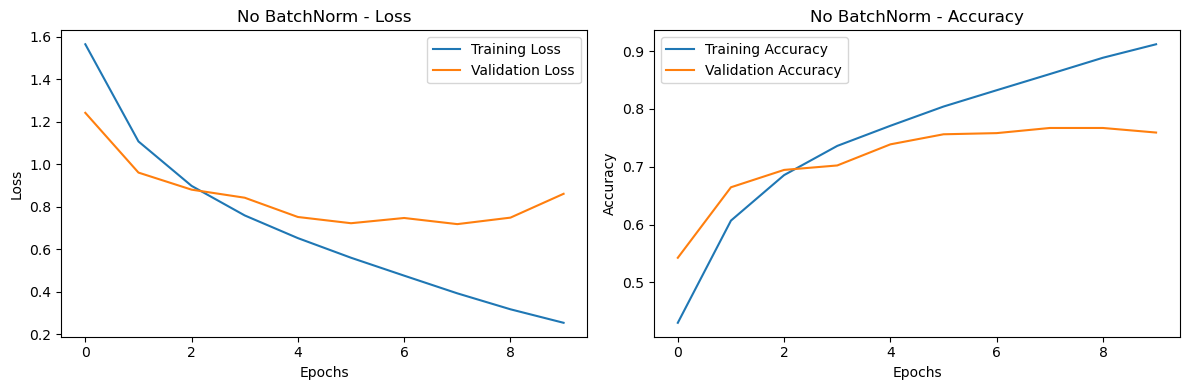

In [87]:
#logging and plotting the results of the experiment
df_no_bn = log_experiment_results("No BatchNorm", history_no_bn, start_time)
plot_history(history_no_bn, "No BatchNorm")

In [88]:
# CNN Model with Batch Normalization
bn_cnn = build_cnn(use_bn=True)
start_time = time.time()  # Record time before training
history_bn = bn_cnn.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 307ms/step - accuracy: 0.4192 - loss: 2.0649 - val_accuracy: 0.2006 - val_loss: 2.9075
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 308ms/step - accuracy: 0.6508 - loss: 0.9876 - val_accuracy: 0.5973 - val_loss: 1.2098
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 317ms/step - accuracy: 0.7334 - loss: 0.7518 - val_accuracy: 0.6430 - val_loss: 1.1033
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 131s 419ms/step - accuracy: 0.7915 - loss: 0.5855 - val_accuracy: 0.6257 - val_loss: 1.1319
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 131s 418ms/step - accuracy: 0.8357 - loss: 0.4554 - val_accuracy: 0.7097 - val_loss: 0.8952
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 391ms/step - accuracy: 0.8820 - loss: 0.3368 - val_accuracy: 0.7211 - val_loss: 0.9484
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 347ms/step - accuracy: 0.9116 - loss: 0.2554 - val_accuracy: 0.7095 - val_loss: 1.0346
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 337ms/step - accuracy: 0.9290 - lo

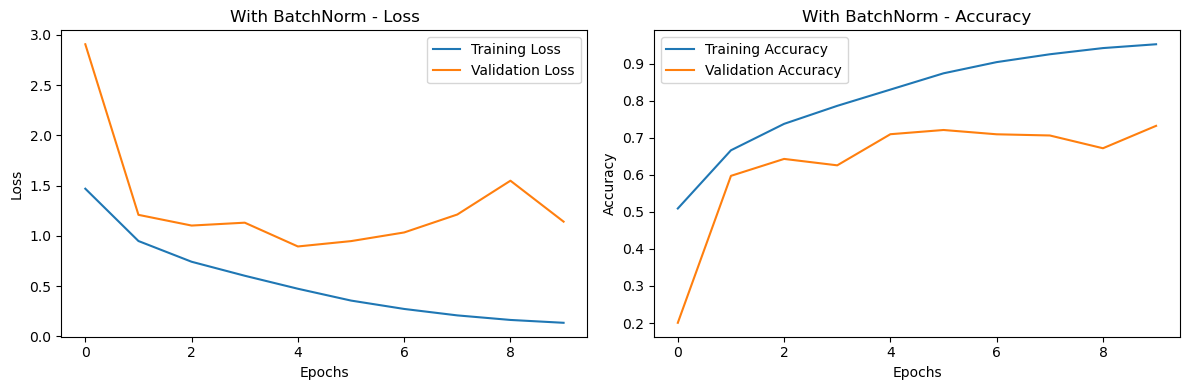

In [89]:
#logging and plotting results
df_bn = log_experiment_results("With BatchNorm", history_bn, start_time)
plot_history(history_bn, "With BatchNorm")

Testing different activation functions

Training with activation function: relu
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 327ms/step - accuracy: 0.4039 - loss: 2.1951 - val_accuracy: 0.1511 - val_loss: 3.5863
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 335ms/step - accuracy: 0.6403 - loss: 1.0141 - val_accuracy: 0.6742 - val_loss: 0.9402
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 114s 365ms/step - accuracy: 0.7299 - loss: 0.7632 - val_accuracy: 0.6881 - val_loss: 0.9177
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 339ms/step - accuracy: 0.7998 - loss: 0.5765 - val_accuracy: 0.6743 - val_loss: 1.0040
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 312ms/step - accuracy: 0.8446 - loss: 0.4408 - val_accuracy: 0.5463 - val_loss: 1.7430
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 314ms/step - accuracy: 0.8864 - loss: 0.3248 - val_accuracy: 0.7355 - val_loss: 0.8202
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.9130 - loss: 0.2446 - val_accuracy: 0.7496 - val_loss: 0.8821
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━

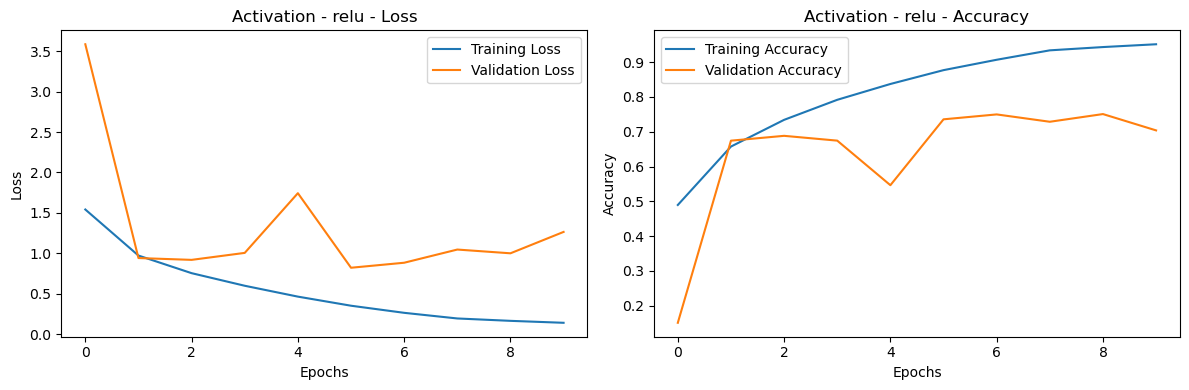

Training with activation function: sigmoid
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 103s 323ms/step - accuracy: 0.4058 - loss: 1.7131 - val_accuracy: 0.0996 - val_loss: 5.0760
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 324ms/step - accuracy: 0.6435 - loss: 1.0038 - val_accuracy: 0.6094 - val_loss: 1.1683
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 322ms/step - accuracy: 0.7396 - loss: 0.7487 - val_accuracy: 0.7152 - val_loss: 0.8161
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.7955 - loss: 0.5888 - val_accuracy: 0.7081 - val_loss: 0.8481
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.8449 - loss: 0.4555 - val_accuracy: 0.7459 - val_loss: 0.7544
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 324ms/step - accuracy: 0.8874 - loss: 0.3404 - val_accuracy: 0.7208 - val_loss: 0.8453
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 325ms/step - accuracy: 0.9153 - loss: 0.2610 - val_accuracy: 0.7566 - val_loss: 0.7458
Epoch 8/10
313/313 ━━━━━━━━━━━━━━

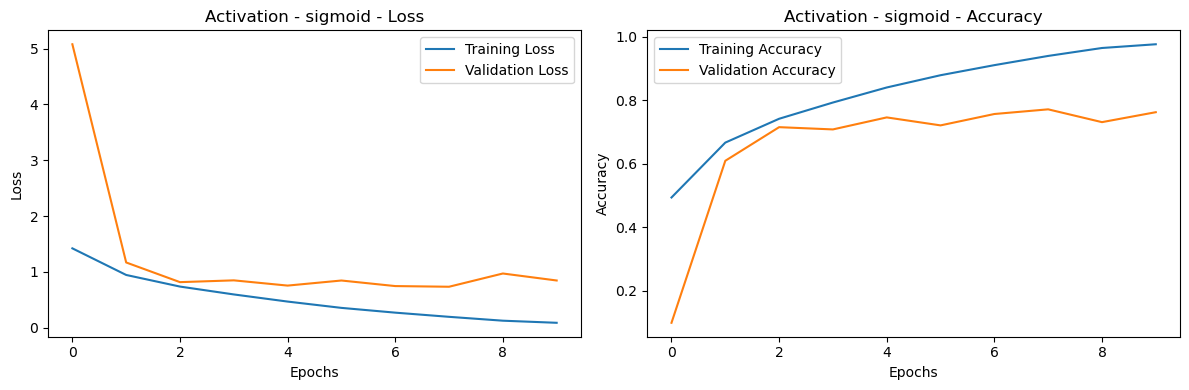

Training with activation function: tanh
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 313ms/step - accuracy: 0.3453 - loss: 2.2812 - val_accuracy: 0.1874 - val_loss: 3.2865
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 321ms/step - accuracy: 0.5695 - loss: 1.2127 - val_accuracy: 0.5885 - val_loss: 1.1647
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 331ms/step - accuracy: 0.6590 - loss: 0.9630 - val_accuracy: 0.6093 - val_loss: 1.1201
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 322ms/step - accuracy: 0.7197 - loss: 0.7909 - val_accuracy: 0.5933 - val_loss: 1.1732
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 321ms/step - accuracy: 0.7576 - loss: 0.6848 - val_accuracy: 0.6166 - val_loss: 1.1218
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.7894 - loss: 0.6012 - val_accuracy: 0.6001 - val_loss: 1.2876
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 314ms/step - accuracy: 0.8243 - loss: 0.4952 - val_accuracy: 0.5743 - val_loss: 1.3796
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━

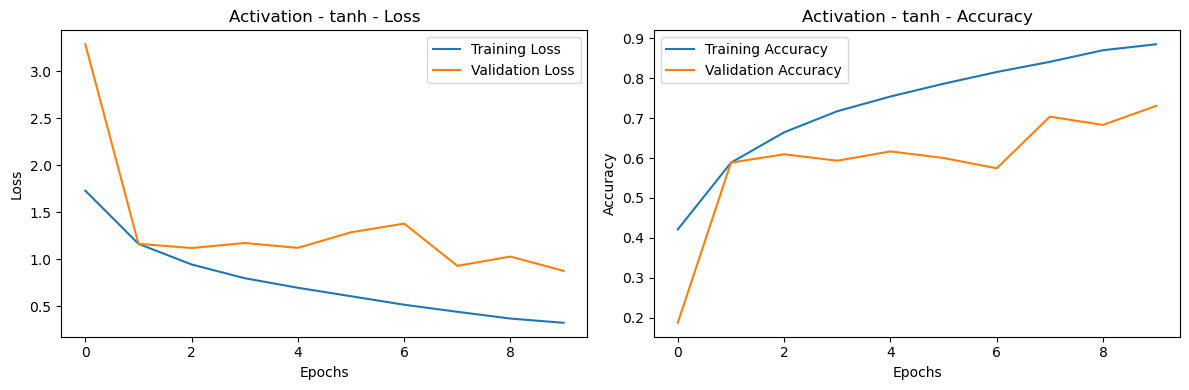

Training with activation function: leaky_relu
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 317ms/step - accuracy: 0.3774 - loss: 2.6866 - val_accuracy: 0.2288 - val_loss: 3.1639
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.6323 - loss: 1.0816 - val_accuracy: 0.6291 - val_loss: 1.0522
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 311ms/step - accuracy: 0.7116 - loss: 0.8394 - val_accuracy: 0.6553 - val_loss: 1.0688
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 317ms/step - accuracy: 0.7725 - loss: 0.6580 - val_accuracy: 0.7207 - val_loss: 0.8487
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.8113 - loss: 0.5351 - val_accuracy: 0.7376 - val_loss: 0.8192
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 318ms/step - accuracy: 0.8518 - loss: 0.4239 - val_accuracy: 0.6883 - val_loss: 1.1417
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.8720 - loss: 0.3630 - val_accuracy: 0.7733 - val_loss: 0.7929
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━

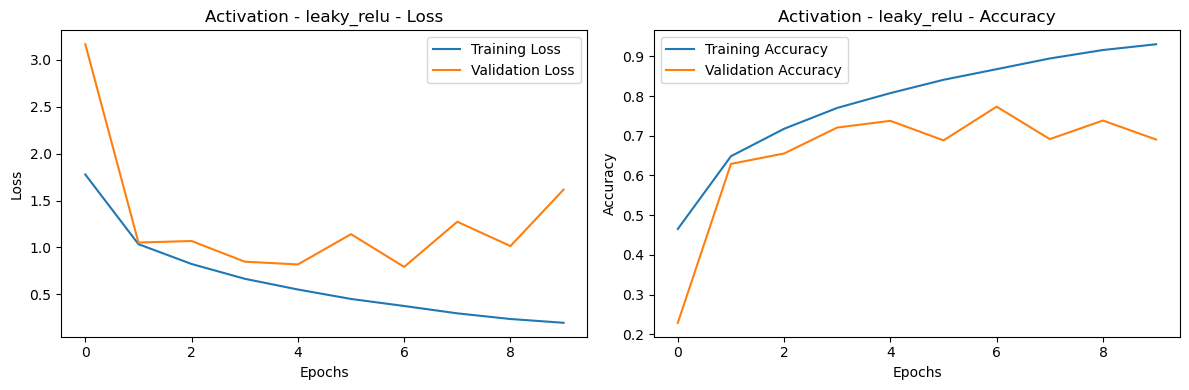

In [98]:
activation_funcs = ["relu", "sigmoid", "tanh", "leaky_relu"] #functoins to test
history_dict = {}

for act_func in activation_funcs:
    print(f"Training with activation function: {act_func}")
    cnn = build_cnn(activation=act_func)
    start_time = time.time()  
    history = cnn.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val))

    # Log and plot results
    history_dict[act_func] = history
    df = log_experiment_results(f"Activation - {act_func}", history, start_time)
    plot_history(history, f"Activation - {act_func}")

Looking at effect of Data Augmentation

In [100]:
# Without Data Augmentation
cnn_no_aug = build_cnn(augment_data=False)
start_time = time.time()
history_no_aug = cnn_no_aug.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 312ms/step - accuracy: 0.4096 - loss: 2.1051 - val_accuracy: 0.1659 - val_loss: 4.0124
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 315ms/step - accuracy: 0.6559 - loss: 0.9804 - val_accuracy: 0.6673 - val_loss: 0.9525
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 311ms/step - accuracy: 0.7331 - loss: 0.7496 - val_accuracy: 0.6938 - val_loss: 0.8924
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 307ms/step - accuracy: 0.7973 - loss: 0.5756 - val_accuracy: 0.6162 - val_loss: 1.1380
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.8405 - loss: 0.4496 - val_accuracy: 0.7219 - val_loss: 0.9121
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.8820 - loss: 0.3317 - val_accuracy: 0.7422 - val_loss: 0.8363
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 310ms/step - accuracy: 0.9111 - loss: 0.2483 - val_accuracy: 0.7185 - val_loss: 0.9998
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 311ms/step - accuracy: 0.9350 - loss: 

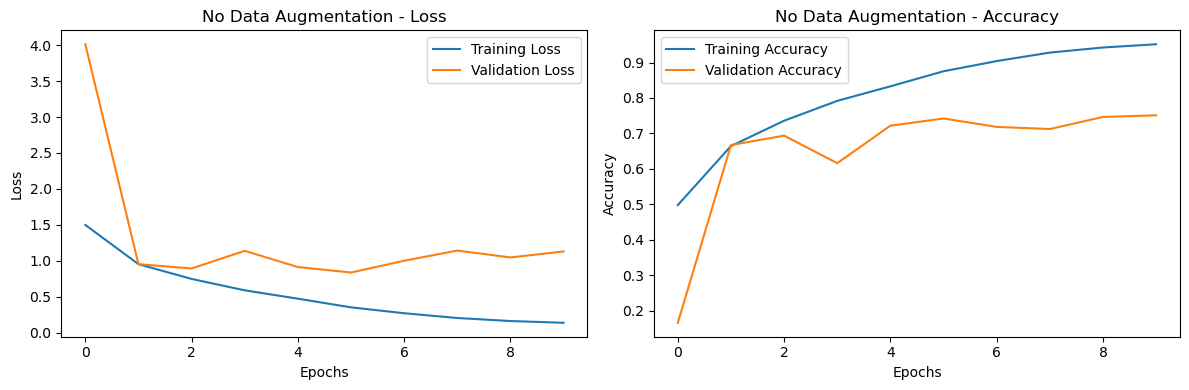

In [101]:
# Logging and plotting results for no data augmentation
df_no_aug = log_experiment_results("No Data Augmentation", history_no_aug, start_time)
plot_history(history_no_aug, "No Data Augmentation")

In [102]:
# With Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

cnn_aug = build_cnn(augment_data=True)
start_time = time.time() #recording start time of training
history_aug = cnn_aug.fit(datagen.flow(x_train, y_train, batch_size=128), epochs=10, validation_data=(x_val, y_val))

Epoch 1/10


C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 339ms/step - accuracy: 0.3200 - loss: 2.4763 - val_accuracy: 0.1894 - val_loss: 2.6312
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 337ms/step - accuracy: 0.4972 - loss: 1.4047 - val_accuracy: 0.3982 - val_loss: 1.9875
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 339ms/step - accuracy: 0.5554 - loss: 1.2394 - val_accuracy: 0.5224 - val_loss: 1.5207
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 336ms/step - accuracy: 0.6037 - loss: 1.1031 - val_accuracy: 0.6402 - val_loss: 1.0554
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 336ms/step - accuracy: 0.6397 - loss: 1.0173 - val_accuracy: 0.6196 - val_loss: 1.1434
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 336ms/step - accuracy: 0.6639 - loss: 0.9541 - val_accuracy: 0.6551 - val_loss: 1.0312
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 333ms/step - accuracy: 0.6881 - loss: 0.8999 - val_accuracy: 0.6858 - val_loss: 0.9263
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 337ms/step - accuracy: 0.6990 - loss: 0.86

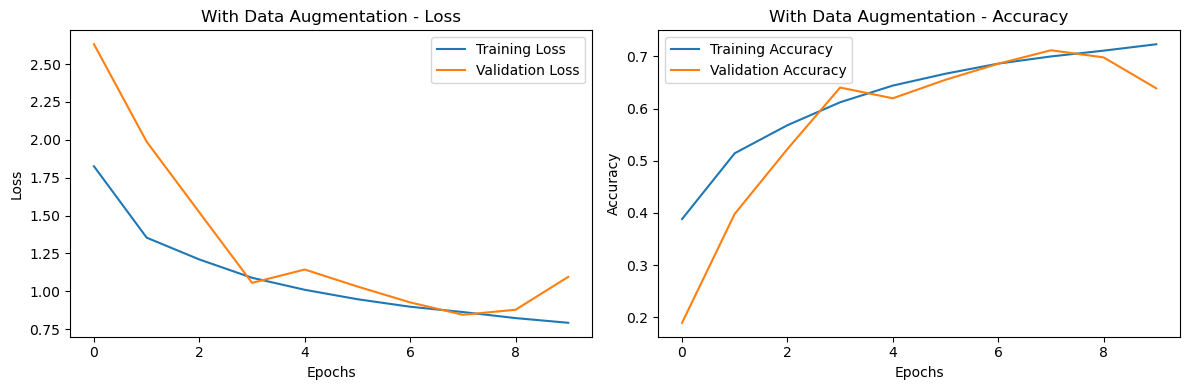

In [103]:
# Log and plot results for data augmentation
df_aug = log_experiment_results("With Data Augmentation", history_aug, start_time)
plot_history(history_aug, "With Data Augmentation")

Comparison between Adam and SGD as optimisers

In [105]:
# Adam optimiser
adam_cnn = build_cnn(optimizer="adam")
start_time = time.time() #recording time of start of experiment
history_adam = adam_cnn.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 309ms/step - accuracy: 0.4111 - loss: 2.0910 - val_accuracy: 0.2318 - val_loss: 2.2203
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.6424 - loss: 1.0035 - val_accuracy: 0.6639 - val_loss: 0.9587
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 310ms/step - accuracy: 0.7339 - loss: 0.7575 - val_accuracy: 0.6776 - val_loss: 0.9262
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 308ms/step - accuracy: 0.7932 - loss: 0.5858 - val_accuracy: 0.7053 - val_loss: 0.8453
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 312ms/step - accuracy: 0.8468 - loss: 0.4378 - val_accuracy: 0.7363 - val_loss: 0.8121
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 310ms/step - accuracy: 0.8856 - loss: 0.3247 - val_accuracy: 0.7447 - val_loss: 0.8133
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 312ms/step - accuracy: 0.9148 - loss: 0.2430 - val_accuracy: 0.7484 - val_loss: 0.8492
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 311ms/step - accuracy: 0.9337 - loss: 0

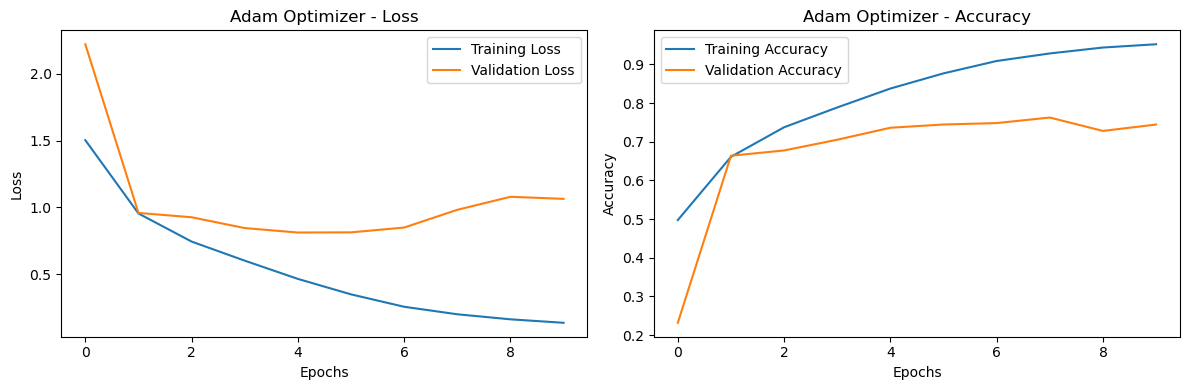

In [106]:
# Results for Adam optimiser
df_adam = log_experiment_results("Adam Optimizer", history_adam, start_time)
plot_history(history_adam, "Adam Optimizer")

In [15]:
# SGD
sgd_cnn = build_cnn(optimizer="sgd")
start_time = time.time() 
history_sgd = sgd_cnn.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 320ms/step - accuracy: 0.4001 - loss: 1.7938 - val_accuracy: 0.3863 - val_loss: 1.7572
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 303ms/step - accuracy: 0.6185 - loss: 1.0790 - val_accuracy: 0.6621 - val_loss: 0.9531
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 104s 331ms/step - accuracy: 0.7103 - loss: 0.8149 - val_accuracy: 0.6845 - val_loss: 0.9317
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 315ms/step - accuracy: 0.7681 - loss: 0.6588 - val_accuracy: 0.6954 - val_loss: 0.9040
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 109s 349ms/step - accuracy: 0.8234 - loss: 0.5043 - val_accuracy: 0.6983 - val_loss: 0.9603
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 310ms/step - accuracy: 0.8638 - loss: 0.3862 - val_accuracy: 0.7226 - val_loss: 0.8520
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 306ms/step - accuracy: 0.9025 - loss: 0.2839 - val_accuracy: 0.7087 - val_loss: 1.0022
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 308ms/step - accuracy: 0.9329 - loss

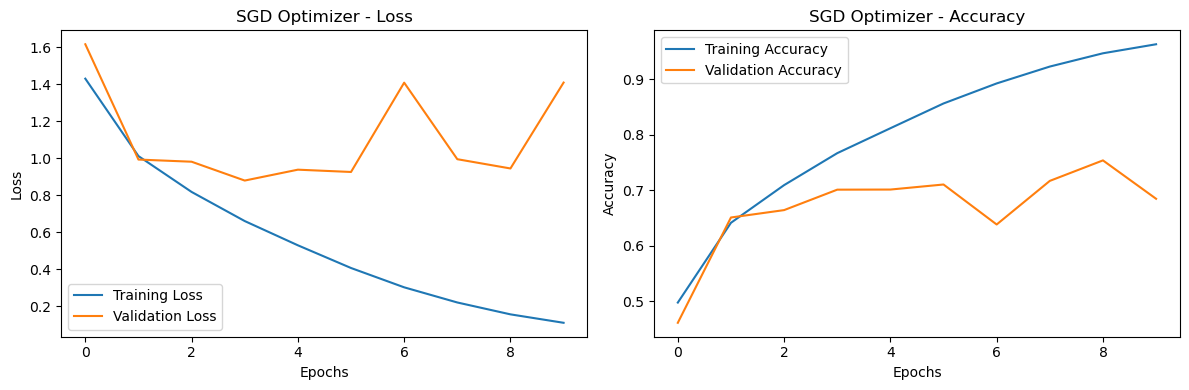

In [108]:
# Log and plot results for SGD optimizer
df_sgd = log_experiment_results("SGD Optimizer", history_sgd, start_time)
plot_history(history_sgd, "SGD Optimizer")

### Comparison against state of the art

##### AlexNet (VGG16 as proxy - available from keras)- with CIFAR-10
I had intended to try this model with FASHION MINST but it was too simple and the grayscale nature did not lend itself to work well with this model

##### ResNet with CIFAR 10

Adding in early stopping to help speed up training

In [152]:
#defining early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train AlexNet (VGG16-style) model
def build_alexnet():
    base_model = VGG16(weights=None, include_top=False, input_shape=(32, 32, 3))
    model = Sequential([
        base_model,
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5), #increasing dropout here to help with overfitting
        Dense(10, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [154]:
# Building ResNet50 model
def build_resnet():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3)) #opting for pre trained weights to help performance
    model = Sequential([
        base_model,
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),# keeping high again like AlexNet model for better reglarisation
        Dense(10, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [156]:
# Train AlexNet
alexnet = build_alexnet()
print("Training AlexNet...")
start_time = time.time()
alexnet_history = alexnet.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val),
                              verbose=1, callbacks=[early_stopping])
elapsed_time_alexnet = time.time() - start_time
print(f"Training time for AlexNet: {elapsed_time_alexnet:.2f} seconds")

Training AlexNet...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 606s 2s/step - accuracy: 0.0988 - loss: 2.3042 - val_accuracy: 0.0933 - val_loss: 2.3030
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 596s 2s/step - accuracy: 0.0995 - loss: 2.3027 - val_accuracy: 0.0933 - val_loss: 2.3028
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 593s 2s/step - accuracy: 0.0995 - loss: 2.3027 - val_accuracy: 0.0933 - val_loss: 2.3028
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 594s 2s/step - accuracy: 0.1042 - loss: 2.3026 - val_accuracy: 0.0933 - val_loss: 2.3028
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 594s 2s/step - accuracy: 0.1012 - loss: 2.3027 - val_accuracy: 0.0933 - val_loss: 2.3028
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 592s 2s/step - accuracy: 0.0991 - loss: 2.3027 - val_accuracy: 0.0933 - val_loss: 2.3028
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 592s 2s/step - accuracy: 0.1010 - loss: 2.3027 - val_accuracy: 0.0979 - val_loss: 2.3030
Training time for AlexNet: 4166.38 seconds


In [157]:
# Track CPU and memory usage after AlexNet training
cpu_after_alexnet, memory_after_alexnet = psutil.cpu_percent(interval=1), psutil.virtual_memory().percent
print(f'CPU after training (AlexNet): {cpu_after_alexnet}%')
print(f'Memory after training (AlexNet): {memory_after_alexnet}%')

CPU after training (AlexNet): 3.1%
Memory after training (AlexNet): 76.4%


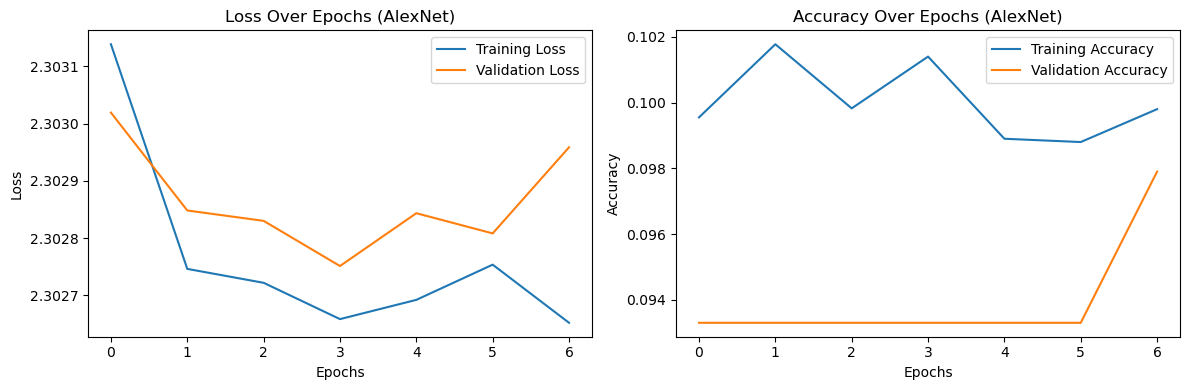

In [158]:
# Plot training history for AlexNet
plt.figure(figsize=(12, 4))
# Loss
plt.subplot(1, 2, 1)
plt.plot(alexnet_history.history['loss'], label='Training Loss')
plt.plot(alexnet_history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs (AlexNet)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(alexnet_history.history['accuracy'], label='Training Accuracy')
plt.plot(alexnet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs (AlexNet)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [159]:
# Making predictions
y_pred_alexnet = alexnet.predict(x_test)

# Converting predictions from one-hot encoding to integer labels
y_pred_alexnet_labels = np.argmax(y_pred_alexnet, axis=1)  # Predicted labels

# Map the integer labels to class names for both true and predicted labels
y_pred_alexnet_classes = [cifar10_classes[label] for label in y_pred_alexnet_labels]
y_true_classes = [cifar10_classes[label] for label in y_true_labels]

313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 154ms/step


In [160]:
# Example predictions:
print(f"True labels (AlexNet): {y_true_classes[:5]}")  # Showing the first 5 true class names
print(f"Predicted labels (AlexNet): {y_pred_alexnet_classes[:5]}")  # Showing the first 5 predicted class names

# Calculate accuracy using sklearn's accuracy_score
acc_alexnet = accuracy_score(y_true_labels, y_pred_alexnet_labels)
print(f"Accuracy using sklearn's accuracy_score for AlexNet: {acc_alexnet}")

True labels (AlexNet): ['Cat', 'Ship', 'Ship', 'Airplane', 'Frog']
Predicted labels (AlexNet): ['Deer', 'Deer', 'Deer', 'Deer', 'Deer']
Accuracy using sklearn's accuracy_score for AlexNet: 0.1


In [161]:
# Save the AlexNet model
alexnet.save('cifar10_alexnet_model.keras')
print("AlexNet model saved successfully.")

AlexNet model saved successfully.


In [162]:
# Training ResNet50
resnet = build_resnet()
print("Training ResNet50...")
start_time = time.time()
resnet_history = resnet.fit(x_train, y_train, epochs=10, batch_size=128, validation_data=(x_val, y_val),
                            verbose=1, callbacks=[early_stopping])
elapsed_time_resnet = time.time() - start_time
print(f"Training time for ResNet50: {elapsed_time_resnet:.2f} seconds")

Training ResNet50...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.4629 - loss: 1.8187 - val_accuracy: 0.0973 - val_loss: 4.1394
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.7400 - loss: 0.7946 - val_accuracy: 0.2630 - val_loss: 2.3455
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.7837 - loss: 0.6534 - val_accuracy: 0.5750 - val_loss: 1.4131
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.8285 - loss: 0.5209 - val_accuracy: 0.7116 - val_loss: 0.9464
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.8383 - loss: 0.4864 - val_accuracy: 0.6950 - val_loss: 0.9945
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 445s 1s/step - accuracy: 0.8616 - loss: 0.4211 - val_accuracy: 0.7733 - val_loss: 0.7268
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.8891 - loss: 0.3433 - val_accuracy: 0.7192 - val_loss: 0.9575
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 444s 1s/step - accuracy: 0.8995 - lo

In [163]:
# Track CPU and memory usage after ResNet50 training
cpu_after_resnet, memory_after_resnet = psutil.cpu_percent(interval=1), psutil.virtual_memory().percent
print(f'CPU after training (ResNet50): {cpu_after_resnet}%')
print(f'Memory after training (ResNet50): {memory_after_resnet}%')

CPU after training (ResNet50): 1.2%
Memory after training (ResNet50): 79.7%


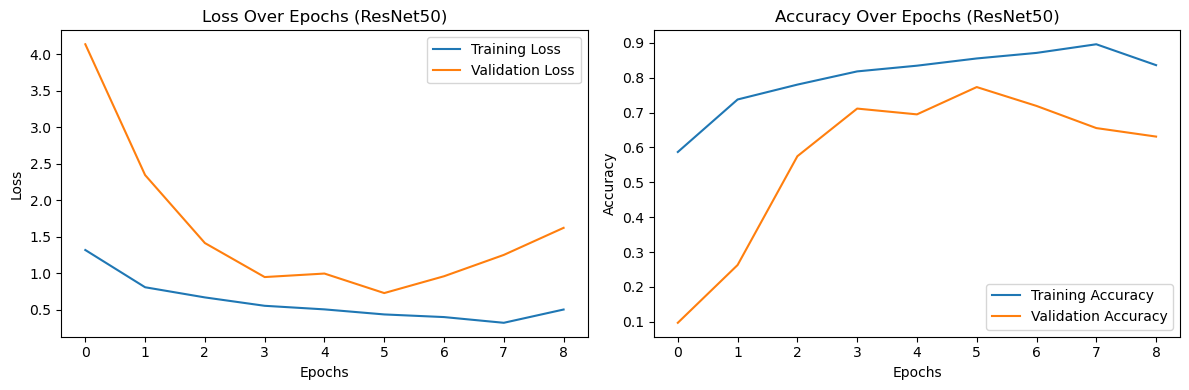

In [164]:
# Plot training history for ResNet50
plt.figure(figsize=(12, 4))
# Loss
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['loss'], label='Training Loss')
plt.plot(resnet_history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs (ResNet50)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['accuracy'], label='Training Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs (ResNet50)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [165]:
#Making predictions on ResNet
y_pred_resnet = resnet.predict(x_test)

# Converting predictions from one-hot encoding to integer labels
y_pred_resnet_labels = np.argmax(y_pred_resnet, axis=1)  # Predicted labels

# Map the integer labels to class names for both true and predicted labels
y_pred_resnet_classes = [cifar10_classes[label] for label in y_pred_resnet_labels]


313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 102ms/step


In [166]:
# Example predictions:
print(f"True labels (ResNet): {y_true_classes[:5]}")  # Showing the first 5 true class names
print(f"Predicted labels (ResNet): {y_pred_resnet_classes[:5]}")  # Showing the first 5 predicted class names

# Calculate accuracy using sklearn's accuracy_score
acc_resnet = accuracy_score(y_true_labels, y_pred_resnet_labels)
print(f"Accuracy using sklearn's accuracy_score for ResNet: {acc_resnet}")

True labels (ResNet): ['Cat', 'Ship', 'Ship', 'Airplane', 'Frog']
Predicted labels (ResNet): ['Cat', 'Automobile', 'Automobile', 'Ship', 'Frog']
Accuracy using sklearn's accuracy_score for ResNet: 0.7612


In [167]:
# Save the ResNet model
resnet.save('cifar10_resnet_model.keras')
print("ResNet model saved successfully.")

ResNet model saved successfully.


### Testing effect of MirroredStrategy on AlexNet and ResNet

In [169]:
# Create the MirroredStrategy - will not be that effective with single node CPU
# Want to show ability to use this code with improved GPU usage etc 
strategy = tf.distribute.MirroredStrategy()

print(f"Number of devices: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
Number of devices: 1


In [170]:
# Use the strategy scope to build and compile the AlexNet model
with strategy.scope():
    alexnet_model = build_alexnet()  

    # Compile the model
    alexnet_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# including early stopping to increase optimisation/ speed up model
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [171]:
# Train the model with the distributed strategy
start_time = time.time()
alexnet_history = alexnet_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)
elapsed_time = time.time() - start_time
print(f"Training time for AlexNet (Distributed): {elapsed_time:.2f} seconds")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.0991 - loss: 2.3028 - val_accuracy: 0.0979 - val_loss: 2.3029
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 592s 2s/step - accuracy: 0.0965 - loss: 2.3027 - val_accuracy: 0.0994 - val_loss: 2.3027
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.1002 - loss: 2.3027 - val_accuracy: 0.0973 - val_loss: 2.3029
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.0958 - loss: 2.3027 - val_accuracy: 0.0933 - val_loss: 2.3028
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.1009 - loss: 2.3026 - val_accuracy: 0.0933 - val_loss: 2.3028
Training time for AlexNet (Distributed): 2961.75 seconds


In [172]:
# Using the strategy scope to build and compile the ResNet model too
with strategy.scope():
    resnet_model = build_resnet()  

    # Compile the model
    resnet_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# ncluding early stopping to increase optimisation/ speed up model
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [173]:
# Train the model with the distributed strategy
start_time = time.time()
resnet_history = resnet_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)
elapsed_time = time.time() - start_time
print(f"Training time for ResNet (Distributed): {elapsed_time:.2f} seconds")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 467s 1s/step - accuracy: 0.4813 - loss: 1.7291 - val_accuracy: 0.0993 - val_loss: 3.1003
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 448s 1s/step - accuracy: 0.7491 - loss: 0.7601 - val_accuracy: 0.2308 - val_loss: 2.7748
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.8076 - loss: 0.5892 - val_accuracy: 0.6598 - val_loss: 1.1004
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 454s 1s/step - accuracy: 0.8430 - loss: 0.4733 - val_accuracy: 0.7472 - val_loss: 0.7913
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 447s 1s/step - accuracy: 0.8740 - loss: 0.3825 - val_accuracy: 0.6699 - val_loss: 1.2154
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.8864 - loss: 0.3469 - val_accuracy: 0.7622 - val_loss: 0.7930
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 444s 1s/step - accuracy: 0.9071 - loss: 0.2848 - val_accuracy: 0.7495 - val_loss: 0.8581
Training time for ResNet (Distributed): 3155.67 seconds


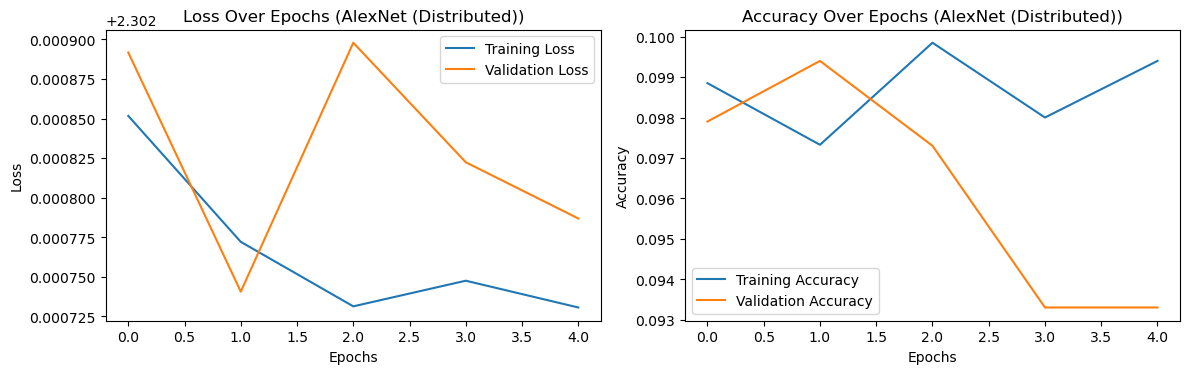

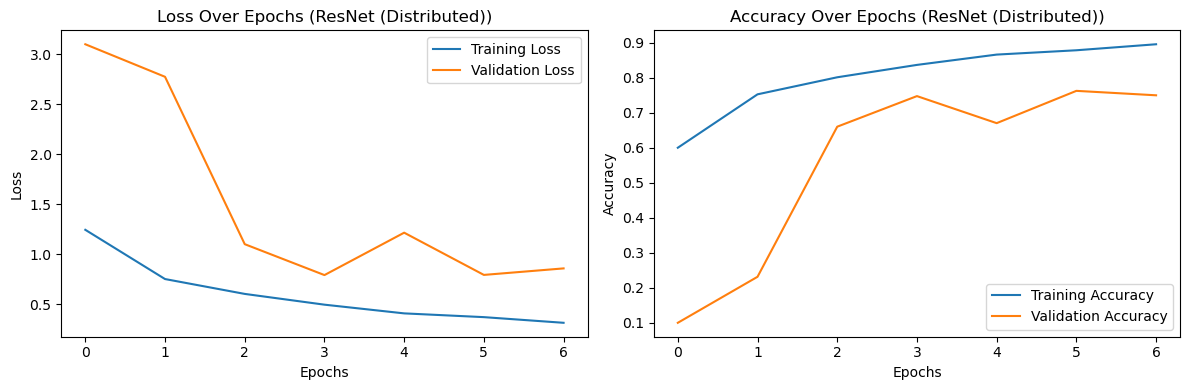

In [174]:
# Plot training history for AlexNet and ResNet with distributed training to compare with single-node

def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss Over Epochs ({model_name})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy Over Epochs ({model_name})')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# After training with distributed strategies (MirroredStrategy) and single-node models:
plot_training_history(alexnet_history, "AlexNet (Distributed)")
plot_training_history(resnet_history, "ResNet (Distributed)")

In [194]:
# Making predictions on AlexNet
y_pred_alexnet = alexnet_model.predict(x_test)

# Convert predictions from one-hot encoding to integer labels
y_pred_alexnet_labels = np.argmax(y_pred_alexnet, axis=1)  # Predicted labels

# Map the integer labels to class names for both true and predicted labels
y_pred_alexnet_classes = [cifar10_classes[label] for label in y_pred_alexnet_labels]

# Example predictions:
print(f"True labels (AlexNet): {y_true_classes[:5]}")  # Showing the first 5 true class names
print(f"Predicted labels (AlexNet): {y_pred_alexnet_classes[:5]}")  # Showing the first 5 predicted class names

# Calculate accuracy using sklearn's accuracy_score
acc_alexnet = accuracy_score(y_true_labels, y_pred_alexnet_labels)
print(f"Accuracy using sklearn's accuracy_score for AlexNet: {acc_alexnet}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step
True labels (AlexNet): ['Cat', 'Ship', 'Ship', 'Airplane', 'Frog']
Predicted labels (AlexNet): ['Horse', 'Horse', 'Horse', 'Horse', 'Horse']
Accuracy using sklearn's accuracy_score for AlexNet: 0.1


In [195]:
# Making predictions on ResNet
y_pred_resnet = resnet_model.predict(x_test)

# Convert predictions from one-hot encoding to integer labels
y_pred_resnet_labels = np.argmax(y_pred_resnet, axis=1)  # Predicted labels

# Map the integer labels to class names for both true and predicted labels
y_pred_resnet_classes = [cifar10_classes[label] for label in y_pred_resnet_labels]

# Example predictions:
print(f"True labels (ResNet): {y_true_classes[:5]}")  # Showing the first 5 true class names
print(f"Predicted labels (ResNet): {y_pred_resnet_classes[:5]}")  # Showing the first 5 predicted class names

# Calculate accuracy using sklearn's accuracy_score
acc_resnet = accuracy_score(y_true_labels, y_pred_resnet_labels)
print(f"Accuracy using sklearn's accuracy_score for ResNet: {acc_resnet}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 108ms/step
True labels (ResNet): ['Cat', 'Ship', 'Ship', 'Airplane', 'Frog']
Predicted labels (ResNet): ['Cat', 'Automobile', 'Ship', 'Airplane', 'Frog']
Accuracy using sklearn's accuracy_score for ResNet: 0.7371


In [197]:
if acc_alexnet > acc_resnet:
    print("AlexNet performed better!")
elif acc_alexnet < acc_resnet:
    print("ResNet performed better!")
else:
    print("Both models have the same accuracy!")

ResNet performed better!


Adapting AlexNet code to better suit CIFAR-10 and improve training accuracy

In [213]:
# AlexNet model adjusted for CIFAR-10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# AlexNet adjusted for CIFAR-10 (Fix for input_shape warning)
def create_alexnet():
    model = Sequential()

    # Explicitly define the Input layer
    model.add(Input(shape=(32,32,3)))

    # Convolutional Layers
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())  
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())  
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))

    # Flatten the layers
    model.add(Flatten())

    # Fully connected layers
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))  # Reduce overfitting
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))  
    model.add(Dense(10, activation='softmax'))  # CIFAR-10 has 10 classes

    # Compile the model
    optimizer = Adam(learning_rate=0.001)  # Adaptive learning rate
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

In [215]:
# Creating the model
alexnet_model = create_alexnet()

In [219]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
# Reduce learning rate on Plateau & reduce Early Stopping
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [221]:
# Data Augmentation to improve generalization
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

In [223]:
start_time = time.time()

# Train the model with data augmentation
alexnet_history = alexnet_model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,  # Increased epochs for better learning
    validation_data=(x_val, y_val),
    callbacks=[lr_scheduler, early_stopping],
    verbose=1
)
elapsed_time = time.time() - start_time
print(f"Training time for AlexNet: {elapsed_time:.2f} seconds")

Epoch 1/50


C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 180ms/step - accuracy: 0.2549 - loss: 2.3626 - val_accuracy: 0.4535 - val_loss: 1.5433 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 181ms/step - accuracy: 0.4293 - loss: 1.5724 - val_accuracy: 0.4649 - val_loss: 1.5152 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 184ms/step - accuracy: 0.4994 - loss: 1.4060 - val_accuracy: 0.4594 - val_loss: 1.6031 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 113s 181ms/step - accuracy: 0.5604 - loss: 1.2476 - val_accuracy: 0.5008 - val_loss: 1.4287 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 184ms/step - accuracy: 0.5961 - loss: 1.1715 - val_accuracy: 0.5624 - val_loss: 1.2605 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 114s 183ms/step - accuracy: 0.6242 - loss: 1.1141 - val_accuracy: 0.7118 - val_loss: 0.8878 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 185ms/step - accuracy: 0.6506 

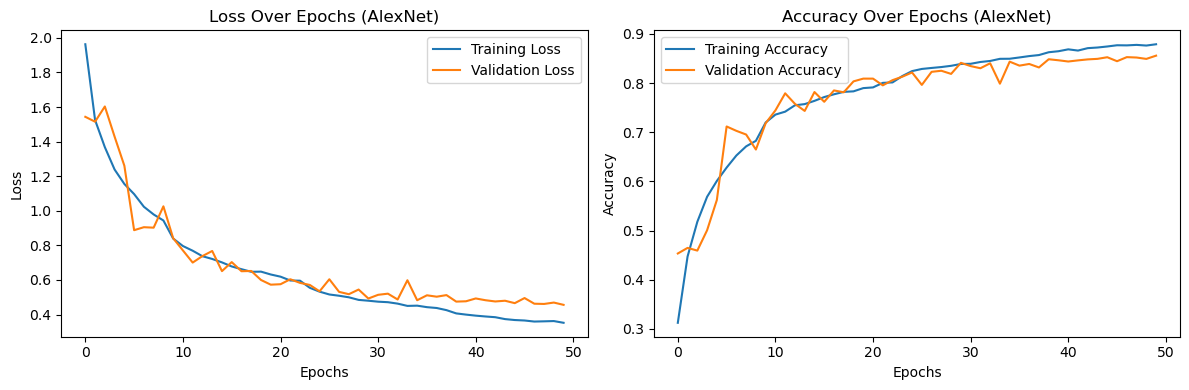

In [224]:
# Ploting training history for adjusted AlexNet
plt.figure(figsize=(12, 4))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(alexnet_history.history['loss'], label='Training Loss')
plt.plot(alexnet_history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs (AlexNet)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(alexnet_history.history['accuracy'], label='Training Accuracy')
plt.plot(alexnet_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs (AlexNet)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [225]:
# Evaluate performance
test_loss, test_acc = alexnet_model.evaluate(x_test, y_test)
print(f"AlexNet Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8519 - loss: 0.4745
AlexNet Test Accuracy: 0.8509
